c:\Users\carlo\.conda\envs\TODO\lib\site-packages\gymnasium\spaces\box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\carlo\.conda\envs\TODO\lib\site-packages\gymnasium\spaces\box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


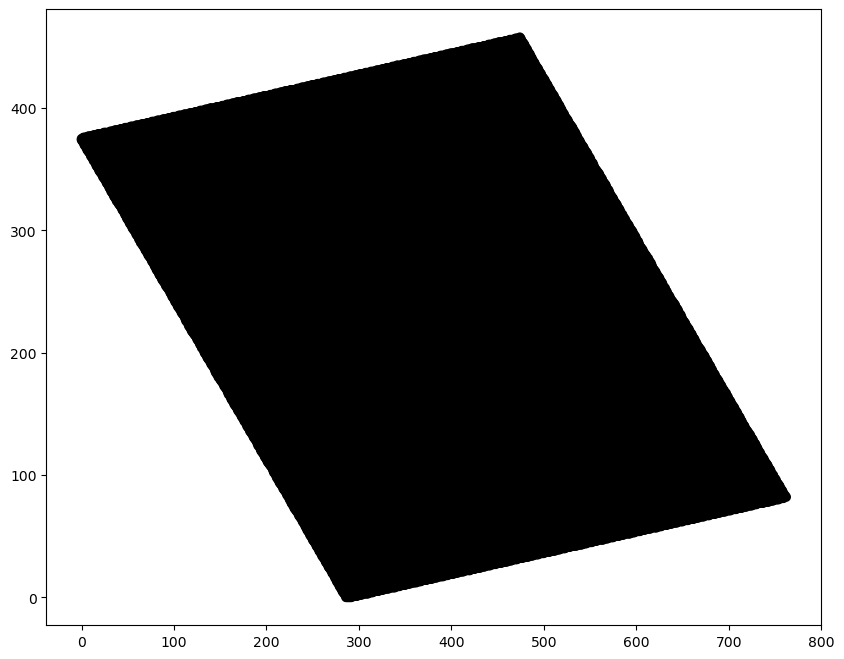

In [ ]:
# ENTORNO DE ENTRADA: env_R11.py (Ruta: ./02_Reinforcement_learning/env_R11.py)

import numpy as np
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import env_R12 
import pandas as pd
from env_R12 import motorEnv2
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')
import os

env = env_R12.motorEnv2()

--- INICIANDO ENTRENAMIENTO PROFUNDO (Objetivo Oculto a 20.535 W) ---


Entrenando:   0%|          | 0/3000 [00:00<?, ?it/s]

Ep    1 | Pasos dados:  773 | Mejor W: 22.556 | Distancia al óptimo: 469.2
Ep  200 | Pasos dados: 1400 | Mejor W: 21.619 | Distancia al óptimo: 368.4
Ep  400 | Pasos dados: 1307 | Mejor W: 20.917 | Distancia al óptimo: 353.0
Ep  600 | Pasos dados: 1871 | Mejor W: 20.623 | Distancia al óptimo: 116.4
Ep  800 | Pasos dados: 1106 | Mejor W: 20.628 | Distancia al óptimo: 208.0
Ep 1000 | Pasos dados:  957 | Mejor W: 20.666 | Distancia al óptimo: 164.0
Ep 1200 | Pasos dados:  863 | Mejor W: 20.628 | Distancia al óptimo: 145.7
Ep 1400 | Pasos dados:  859 | Mejor W: 20.628 | Distancia al óptimo: 145.7
Ep 1600 | Pasos dados:  850 | Mejor W: 20.628 | Distancia al óptimo: 143.8
Ep 1800 | Pasos dados:  827 | Mejor W: 20.628 | Distancia al óptimo: 134.1
Ep 2000 | Pasos dados:  821 | Mejor W: 20.628 | Distancia al óptimo: 137.4
Ep 2200 | Pasos dados:  866 | Mejor W: 20.628 | Distancia al óptimo: 132.1
Ep 2400 | Pasos dados:  810 | Mejor W: 20.628 | Distancia al óptimo: 132.1
Ep 2600 | Pasos dados:  8

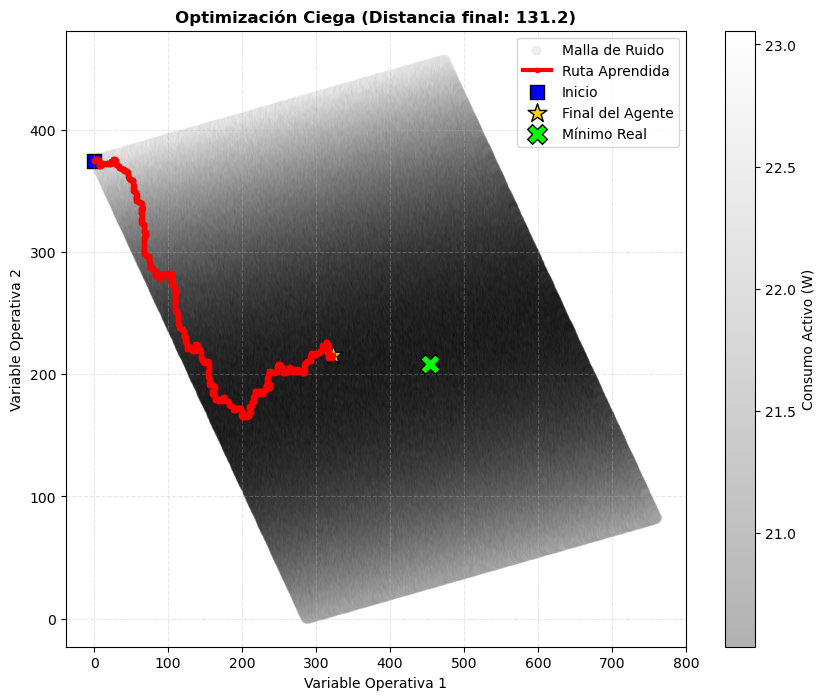

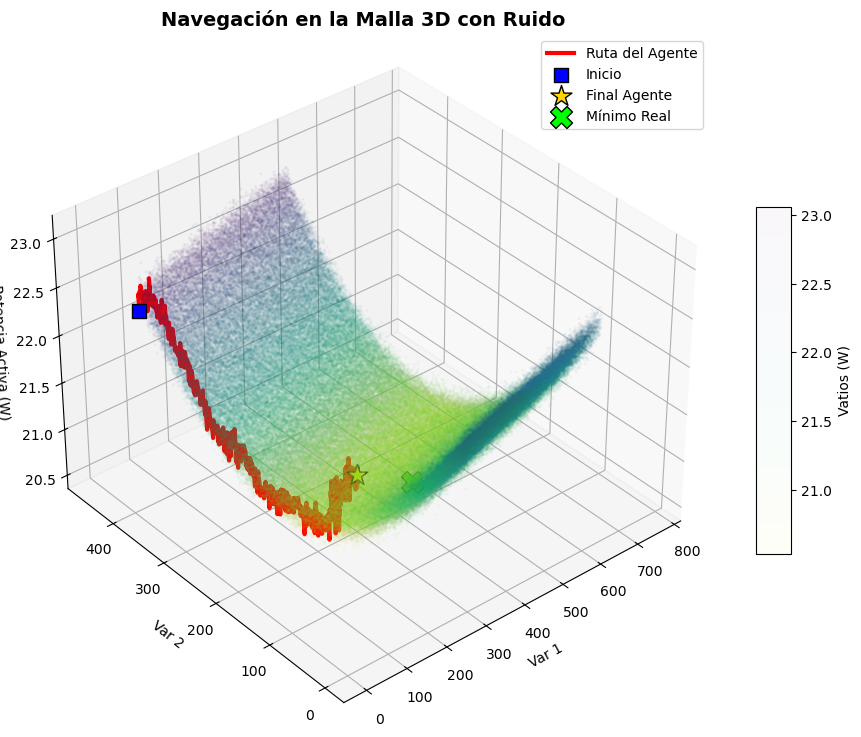

In [ ]:
# FASE 1: Tolerancia al Ruido

UMBRAL_RUIDO          = 0.05   
UMBRAL_CUESTA         = 0.20   
REWARD_BAJA           = +10    
REWARD_RUIDO          =  -1    
REWARD_CUESTA_PEQ     =  -5    
REWARD_CUESTA_GRA     = -20    
PENALIZACION_VISITADO = -15 
PASOS_ESTANCAMIENTO   = 5    
PENALIZACION_ESTANC   = -10  
LIMITE_ESTANCAMIENTO_TOTAL = 300 

def reward_shaping(recompensa_base, w_antiguo, w_nuevo, estado_nuevo, estados_visitados, historial_w):
    reward = recompensa_base
    diff_w = w_nuevo - w_antiguo

    # 1. Gradiente y Tolerancia al Ruido
    if diff_w < 0:
        reward += REWARD_BAJA
    elif diff_w <= UMBRAL_RUIDO:
        reward += REWARD_RUIDO
    elif diff_w <= UMBRAL_CUESTA:
        reward += REWARD_CUESTA_PEQ
    else:
        reward += REWARD_CUESTA_GRA

    # 2. Exploración (Evitar bucles)
    if estado_nuevo in estados_visitados:
        reward += PENALIZACION_VISITADO

    # 3. Antiestancamiento local
    if len(historial_w) >= PASOS_ESTANCAMIENTO:
        ultimos = historial_w[-PASOS_ESTANCAMIENTO:]
        if max(ultimos) - min(ultimos) < 1e-6:  
            reward += PENALIZACION_ESTANC
    return reward

# 2. INICIALIZACIÓN Y EXTRACCIÓN DEL OBJETIVO

env = motorEnv2()
num_estados  = len(env.rot)
num_acciones = env.action_space.n
q_table      = np.zeros((num_estados, num_acciones))

fila_minima_real = env.rot.loc[env.rot['w'].idxmin()]
VAR1_OBJETIVO = fila_minima_real['var1']
VAR2_OBJETIVO = fila_minima_real['var2']
W_MIN_REAL    = fila_minima_real['w']

alpha = 0.2
gamma = 0.99
decay = 0.998 
epsilon = 1.0
epsilon_min = 0.01
episodios_entrenamiento = 3000
max_pasos_por_episodio = 3500 

print(f"--- INICIANDO ENTRENAMIENTO PROFUNDO (Objetivo Oculto a {W_MIN_REAL:.3f} W) ---")

# 3. BUCLE DE ENTRENAMIENTO

for episodio in tqdm(range(episodios_entrenamiento), desc="Entrenando"):
    env.reset()
    estado = 0
    done   = False
    pasos_dados = 0
    
    mejor_w_episodio = float('inf')
    pasos_sin_mejorar = 0
    distancia_minima_lograda = float('inf')

    estados_visitados = set([0])
    historial_w = [env.rot.iloc[0]['w']]

    while not done and pasos_dados < max_pasos_por_episodio:
        if random.uniform(0, 1) < epsilon:
            accion = env.action_space.sample()
        else:
            accion = np.argmax(q_table[estado])

        paso = env.step(accion)
        if len(paso) == 4:
            siguiente_estado, recompensa_env, done_env, _ = paso
        else:
            siguiente_estado, recompensa_env, done_env, truncated, _ = paso
            
        w_antiguo = env.rot.iloc[estado]['w']
        w_nuevo   = env.rot.iloc[siguiente_estado]['w']
        
        var1_nue = env.rot.iloc[siguiente_estado]['var1']
        var2_nue = env.rot.iloc[siguiente_estado]['var2']
        dist_actual = np.sqrt((var1_nue - VAR1_OBJETIVO)**2 + (var2_nue - VAR2_OBJETIVO)**2)
        
        if dist_actual < distancia_minima_lograda:
            distancia_minima_lograda = dist_actual

        if w_nuevo < mejor_w_episodio:
            mejor_w_episodio = w_nuevo
            pasos_sin_mejorar = 0
        else:
            pasos_sin_mejorar += 1

        if pasos_sin_mejorar >= LIMITE_ESTANCAMIENTO_TOTAL:
            done = True

        recompensa_base = 0 if recompensa_env > 0 else recompensa_env
        recompensa_guiada = reward_shaping(recompensa_base, w_antiguo, w_nuevo, siguiente_estado, estados_visitados, historial_w)
        valor_antiguo  = q_table[estado, accion]
        proximo_maximo = np.max(q_table[siguiente_estado])
        q_table[estado, accion] = valor_antiguo + alpha * (recompensa_guiada + gamma * proximo_maximo - valor_antiguo)

        estados_visitados.add(siguiente_estado)
        historial_w.append(w_nuevo)
        if len(historial_w) > PASOS_ESTANCAMIENTO + 1:
            historial_w.pop(0)
        estado = siguiente_estado
        pasos_dados += 1
    if epsilon > epsilon_min:
        epsilon *= decay
    if (episodio + 1) % 200 == 0 or episodio == 0:
        print(f"Ep {episodio+1:4d} | Pasos dados: {pasos_dados:4d} | Mejor W: {mejor_w_episodio:.3f} | Distancia al óptimo: {distancia_minima_lograda:.1f}")
plt.close('all')
print("\nEntrenamiento finalizado.")
np.save('Datos/Transformados/q_table_entrenada.npy', q_table)

# 4. EVALUACIÓN Y EXTRACCIÓN DEL CAMINO APRENDIDO

print("--- EVALUACIÓN FINAL DE LA RUTA ---")
env.reset()
estado = 0
done   = False
pasos_dados = 0
mejor_w_eval = float('inf')
pasos_sin_mejorar_eval = 0
camino_var1, camino_var2, camino_w = [], [], []

while not done and pasos_dados < max_pasos_por_episodio:
    camino_var1.append(env.rot.iloc[estado]['var1'])
    camino_var2.append(env.rot.iloc[estado]['var2'])
    camino_w.append(env.rot.iloc[estado]['w'])

    accion = np.argmax(q_table[estado])
    paso = env.step(accion)
    estado = paso[0]
    w_nuevo = env.rot.iloc[estado]['w']

    if w_nuevo < mejor_w_eval:
        mejor_w_eval = w_nuevo
        pasos_sin_mejorar_eval = 0
    else:
        pasos_sin_mejorar_eval += 1
    if pasos_sin_mejorar_eval >= LIMITE_ESTANCAMIENTO_TOTAL:
        done = True
    pasos_dados += 1

camino_var1.append(env.rot.iloc[estado]['var1'])
camino_var2.append(env.rot.iloc[estado]['var2'])
camino_w.append(env.rot.iloc[estado]['w'])

df_ruta = pd.DataFrame({'var1': camino_var1, 'var2': camino_var2, 'consumo_W': camino_w})
df_ruta.to_csv('Datos/Transformados/ruta_optima_ciega_profunda.csv', index=False)
distancia_final = np.sqrt((camino_var1[-1] - VAR1_OBJETIVO)**2 + (camino_var2[-1] - VAR2_OBJETIVO)**2)

print(f"El agente se detuvo en el paso {pasos_dados} por estabilidad de W.")
print(f"W final alcanzado  : {camino_w[-1]:.6f} W")
print(f"W mínimo real      : {W_MIN_REAL:.6f} W")
print(f"Distancia restante : {distancia_final:.1f} baldosas")

# 5. VISUALIZACIÓN: RUTAS 2D Y 3D

df_fondo = env.rot
plt.figure(figsize=(10, 8))
plt.scatter(df_fondo['var1'], df_fondo['var2'], c=df_fondo['w'], cmap='gray', alpha=0.3, label='Malla de Ruido')
cb = plt.colorbar()
cb.set_label('Consumo Activo (W)')
plt.plot(df_ruta['var1'], df_ruta['var2'], color='red', linewidth=3, marker='o', markersize=3, label='Ruta Aprendida')
plt.scatter(df_ruta['var1'].iloc[0], df_ruta['var2'].iloc[0], color='blue', s=100, marker='s', edgecolors='black', label='Inicio')
plt.scatter(df_ruta['var1'].iloc[-1], df_ruta['var2'].iloc[-1], color='gold', s=200, marker='*', edgecolors='black', label='Final del Agente')
plt.scatter(VAR1_OBJETIVO, VAR2_OBJETIVO, color='lime', s=200, marker='X', edgecolors='black', label='Mínimo Real')
plt.title(f"Optimización Ciega (Distancia final: {distancia_final:.1f})", fontweight='bold')
plt.xlabel('Variable Operativa 1')
plt.ylabel('Variable Operativa 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(df_fondo['var1'], df_fondo['var2'], df_fondo['w'], c=df_fondo['w'], cmap='viridis_r', alpha=0.03, s=2)
ax.plot(df_ruta['var1'], df_ruta['var2'], df_ruta['consumo_W'], color='red', linewidth=3, alpha=1.0, label='Ruta del Agente')
ax.scatter(df_ruta['var1'].iloc[0], df_ruta['var2'].iloc[0], df_ruta['consumo_W'].iloc[0], color='blue', s=100, marker='s', edgecolors='black', label='Inicio')
ax.scatter(df_ruta['var1'].iloc[-1], df_ruta['var2'].iloc[-1], df_ruta['consumo_W'].iloc[-1], color='gold', s=250, marker='*', edgecolors='black', label='Final Agente')
ax.scatter(VAR1_OBJETIVO, VAR2_OBJETIVO, W_MIN_REAL, color='lime', s=250, marker='X', edgecolors='black', label='Mínimo Real')
ax.set_title("Navegación en la Malla 3D con Ruido", fontweight='bold', fontsize=14)
ax.set_xlabel('Var 1')
ax.set_ylabel('Var 2')
ax.set_zlabel('Potencia Activa (W)')
ax.view_init(elev=35, azim=230) 
fig.colorbar(p, ax=ax, label='Vatios (W)', shrink=0.5, aspect=10)
ax.legend()
plt.show()

In [ ]:
# FASE 2: Exploración y antiestancamiento

# 1. REWARD SHAPING
def reward_shaping_honesto(w_antiguo, w_nuevo, estado_nuevo, visitas_globales):
    diff_w = w_antiguo - w_nuevo
    reward = diff_w * 100 
    visitas = visitas_globales[estado_nuevo]
    reward -= (visitas * 0.08)
    return reward

# 2. CARGA DEL Q-TABLE PREVIO
num_estados  = len(env.rot)
num_acciones = env.action_space.n
q_table = np.load('Datos/Transformados/q_table_entrenada.npy')

# 3. ENTRENAMIENTO CIEGO 
alpha = 0.1         
gamma = 0.99
decay = 0.995       
epsilon = 0.30       
epsilon_min = 0.10   
episodios_entrenamiento = 1500  
visitas_globales = np.zeros(num_estados)

mejor_w_historico = float('inf') 
mejor_v1_historico = 0
mejor_v2_historico = 0

print("INICIANDO BÚSQUEDA MASIVA")

for episodio in tqdm(range(episodios_entrenamiento), desc="Exploración Global", unit="ep"):
    env.reset()
    
    estado = random.randint(0, num_estados - 1)
    env.var1 = env.rot.iloc[estado]['var1']
    env.var2 = env.rot.iloc[estado]['var2']
    env.old_state = estado
    done   = False
    pasos_dados = 0
    mejor_w_episodio = env.rot.iloc[estado]['w']
    v1_episodio = env.var1
    v2_episodio = env.var2

    while not done and pasos_dados < 3000:
        if random.uniform(0, 1) < epsilon:
            accion = env.action_space.sample()
        else:
            accion = np.argmax(q_table[estado])

        paso = env.step(accion)
        if len(paso) == 4:
            siguiente_estado, _, done_env, _ = paso
        else:
            siguiente_estado, _, done_env, truncated, _ = paso
        w_antiguo = env.rot.iloc[estado]['w']
        w_nuevo   = env.rot.iloc[siguiente_estado]['w']
        visitas_globales[siguiente_estado] += 1

        if w_nuevo < mejor_w_episodio:
            mejor_w_episodio = w_nuevo
            v1_episodio = env.rot.iloc[siguiente_estado]['var1']
            v2_episodio = env.rot.iloc[siguiente_estado]['var2']

        if pasos_dados > 2800: 
            done = True

        r_guiada = reward_shaping_honesto(w_antiguo, w_nuevo, siguiente_estado, visitas_globales)
        v_ant  = q_table[estado, accion]
        v_prox = np.max(q_table[siguiente_estado])
        q_table[estado, accion] = v_ant + alpha * (r_guiada + gamma * v_prox - v_ant)
        estado = siguiente_estado
        pasos_dados += 1

    if epsilon > epsilon_min: 
        epsilon *= decay

    if mejor_w_episodio < mejor_w_historico:
        mejor_w_historico = mejor_w_episodio
        mejor_v1_historico = v1_episodio
        mejor_v2_historico = v2_episodio
        
        np.save('Datos/Transformados/q_table_definitiva.npy', q_table)
        np.save('Datos/Transformados/meta_descubierta.npy', np.array([mejor_v1_historico, mejor_v2_historico, mejor_w_historico]))
        nuevo_record = True
    else:
        nuevo_record = False
    if (episodio + 1) % 50 == 0 or episodio == 0 or nuevo_record:
        tag = " RÉCORD GUARDADO!" if nuevo_record else ""
        print(f"Ep {episodio+1:4d} | Mejor W cazado: {mejor_w_episodio:.3f} W | Máx lava: {int(np.max(visitas_globales))}{tag}")

print(f"\nFase 2 finalizada. El agente descubrió un mínimo de: {mejor_w_historico:.6f} W")
print(f"Coordenadas guardadas de forma segura en 'meta_descubierta.npy'")

✅ CEREBRO CARGADO: Restaurando la base de conocimiento de la Fase 1.
--- INICIANDO BÚSQUEDA MASIVA (100% CIEGA) ---


Exploración Global:   0%|          | 0/1500 [00:00<?, ?ep/s]

Ep    1 | Mejor W cazado: 20.697 W | Máx lava: 96 🏆 RÉCORD GUARDADO!
Ep   11 | Mejor W cazado: 20.607 W | Máx lava: 139 🏆 RÉCORD GUARDADO!
Ep   24 | Mejor W cazado: 20.606 W | Máx lava: 145 🏆 RÉCORD GUARDADO!
Ep   50 | Mejor W cazado: 21.007 W | Máx lava: 151
Ep  100 | Mejor W cazado: 21.211 W | Máx lava: 156
Ep  150 | Mejor W cazado: 20.705 W | Máx lava: 165
Ep  200 | Mejor W cazado: 20.843 W | Máx lava: 185
Ep  250 | Mejor W cazado: 20.620 W | Máx lava: 188
Ep  300 | Mejor W cazado: 20.774 W | Máx lava: 188
Ep  337 | Mejor W cazado: 20.602 W | Máx lava: 188 🏆 RÉCORD GUARDADO!
Ep  350 | Mejor W cazado: 21.103 W | Máx lava: 188
Ep  400 | Mejor W cazado: 21.079 W | Máx lava: 193
Ep  450 | Mejor W cazado: 20.857 W | Máx lava: 193
Ep  456 | Mejor W cazado: 20.585 W | Máx lava: 193 🏆 RÉCORD GUARDADO!
Ep  500 | Mejor W cazado: 20.895 W | Máx lava: 193
Ep  550 | Mejor W cazado: 21.501 W | Máx lava: 193
Ep  600 | Mejor W cazado: 21.220 W | Máx lava: 208
Ep  635 | Mejor W cazado: 20.535 W | Má

✅ CEREBRO Y MEMORIA CARGADOS.
🎯 El agente se dirige a su propio descubrimiento: 20.535195 W
--- TRAZANDO AUTOPISTA ---


Pulido Final:   0%|          | 0/1000 [00:00<?, ?ep/s]

✅ Autopista conectada. Preparando despliegue final.

--- CALCULANDO LA RUTA DEFINITIVA ---
--------------------------------------------------
🏆 RESULTADOS FINALES DE LA MISIÓN
--------------------------------------------------
Objetivo fijado por el agente : 20.535195 W
W final alcanzado (Agente)    : 20.535195 W
Distancia Final a la meta     : 0.0 baldosas
Número de pasos exactos       : 686 pasos
--------------------------------------------------


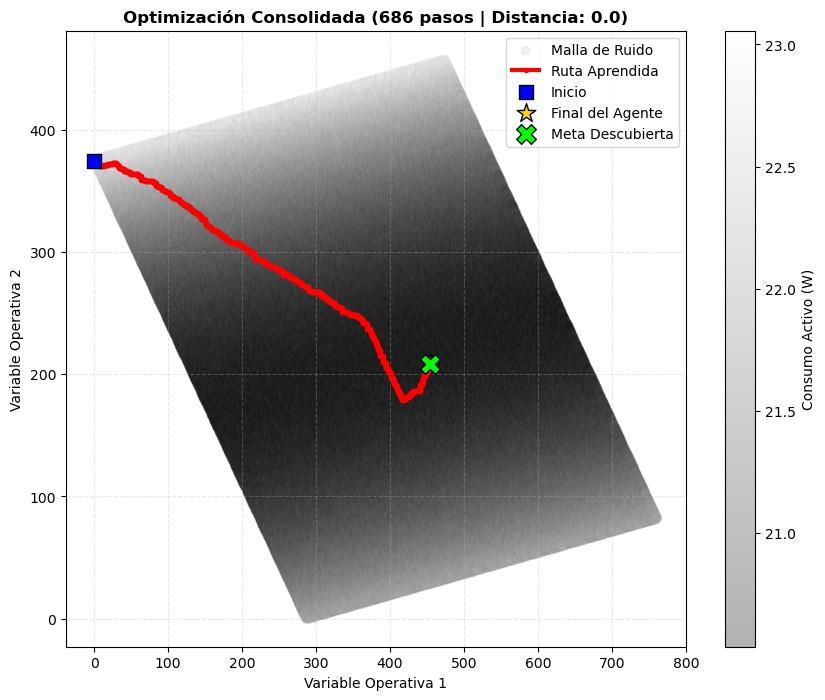

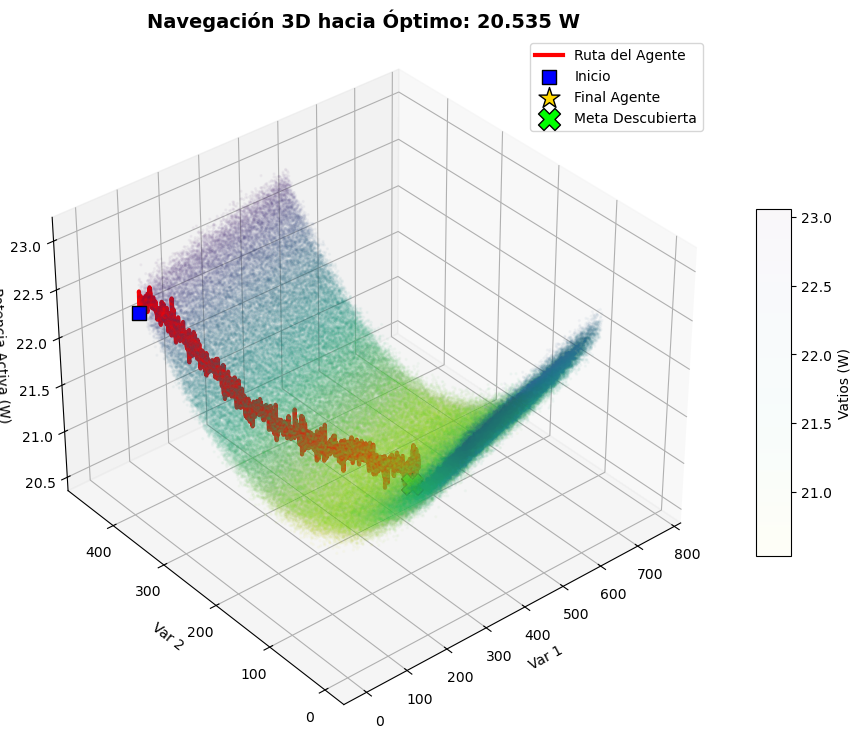

In [ ]:
# FASE 3: Explotación de la ruta más óptima


# 1. CARGA DEL Q-TABLE
q_table = np.load('Datos/Transformados/q_table_definitiva.npy')
q_table[q_table < 0] = 0 
meta_guardada = np.load('Datos/Transformados/meta_descubierta.npy')
VAR1_OBJETIVO = meta_guardada[0]
VAR2_OBJETIVO = meta_guardada[1]
W_MIN_DESCUBIERTO = meta_guardada[2]

print("CEREBRO Y MEMORIA CARGADOS.")
print(f"El agente se dirige a su propio descubrimiento: {W_MIN_DESCUBIERTO:.6f} W")

# 2. LA BRÚJULA EQUILIBRADA 
def reward_equilibrado(w_antiguo, w_nuevo, estado_ant, estado_nue):
    diff_w = w_antiguo - w_nuevo
    r_base = diff_w * 50 

    v1_ant = env.rot.iloc[estado_ant]['var1']
    v2_ant = env.rot.iloc[estado_ant]['var2']
    dist_ant = np.sqrt((v1_ant - VAR1_OBJETIVO)**2 + (v2_ant - VAR2_OBJETIVO)**2)
    v1_nue = env.rot.iloc[estado_nue]['var1']
    v2_nue = env.rot.iloc[estado_nue]['var2']
    dist_nue = np.sqrt((v1_nue - VAR1_OBJETIVO)**2 + (v2_nue - VAR2_OBJETIVO)**2)
    r_gps = (dist_ant - dist_nue) * 500 
    r_step = -1 
    return r_base + r_gps + r_step

# 3. ENTRENAMIENTO DE CONEXIÓN
alpha = 0.1         
gamma = 0.99
decay = 0.995       
epsilon = 1.0       
epsilon_min = 0.01  
episodios_conexion = 1000  

print(f"TRAZANDO")

for episodio in tqdm(range(episodios_conexion), desc="Pulido Final", unit="ep"): 
    env.reset()
    estado = 0  
    done   = False
    pasos_dados = 0
    mejor_w_episodio = env.rot.iloc[estado]['w']
    while not done and pasos_dados < 3000:
        if random.uniform(0, 1) < epsilon:
            accion = env.action_space.sample()
        else:
            accion = np.argmax(q_table[estado])

        paso = env.step(accion)
        if len(paso) == 4:
            siguiente_estado, _, done_env, _ = paso
        else:
            siguiente_estado, _, done_env, truncated, _ = paso
        w_antiguo = env.rot.iloc[estado]['w']
        w_nuevo   = env.rot.iloc[siguiente_estado]['w']
        if w_nuevo < mejor_w_episodio:
            mejor_w_episodio = w_nuevo

        if pasos_dados > 2000: 
            done = True
        r_total = reward_equilibrado(w_antiguo, w_nuevo, estado, siguiente_estado)
        v_ant  = q_table[estado, accion]
        v_prox = np.max(q_table[siguiente_estado])
        q_table[estado, accion] = v_ant + alpha * (r_total + gamma * v_prox - v_ant)
        estado = siguiente_estado
        pasos_dados += 1

    if epsilon > epsilon_min: 
        epsilon *= decay

print(f"Preparando despliegue final")

# 4. EVALUACIÓN FINAL 

print("\n--- CALCULANDO LA RUTA DEFINITIVA ---")
env.reset()
estado = 0
done = False
camino_var1, camino_var2, camino_w = [], [], []
pasos_sin_mejorar_eval = 0
mejor_w_eval = float('inf')
while not done and len(camino_w) < 4000:
    camino_var1.append(env.rot.iloc[estado]['var1'])
    camino_var2.append(env.rot.iloc[estado]['var2'])
    w_actual = env.rot.iloc[estado]['w']
    camino_w.append(w_actual)
    accion = np.argmax(q_table[estado])
    paso = env.step(accion)
    estado = paso[0]

    if w_actual < mejor_w_eval:
        mejor_w_eval = w_actual
        pasos_sin_mejorar_eval = 0
    else:
        pasos_sin_mejorar_eval += 1

    if pasos_sin_mejorar_eval > 800: 
        done = True
if pasos_sin_mejorar_eval > 0 and len(camino_w) > pasos_sin_mejorar_eval:
    camino_var1 = camino_var1[:-pasos_sin_mejorar_eval]
    camino_var2 = camino_var2[:-pasos_sin_mejorar_eval]
    camino_w    = camino_w[:-pasos_sin_mejorar_eval]

distancia_final = np.sqrt((camino_var1[-1] - VAR1_OBJETIVO)**2 + (camino_var2[-1] - VAR2_OBJETIVO)**2)
num_pasos = len(camino_w) - 1
df_ruta = pd.DataFrame({'var1': camino_var1, 'var2': camino_var2, 'consumo_W': camino_w})
df_ruta.to_csv('Datos/Transformados/ruta_optima_definitiva.csv', index=False)

print(f"Objetivo fijado por el agente : {W_MIN_DESCUBIERTO:.6f} W")
print(f"W final alcanzado (Agente)    : {camino_w[-1]:.6f} W")
print(f"Distancia Final a la meta     : {distancia_final:.1f} baldosas")
print(f"Número de pasos exactos       : {num_pasos} pasos")

# 5. VISUALIZACIÓN: RUTAS 2D Y 3D

df_fondo = env.rot
plt.figure(figsize=(10, 8))
plt.scatter(df_fondo['var1'], df_fondo['var2'], c=df_fondo['w'], cmap='gray', alpha=0.3, label='Malla de Ruido')
cb = plt.colorbar()
cb.set_label('Consumo Activo (W)')
plt.plot(df_ruta['var1'], df_ruta['var2'], color='red', linewidth=3, marker='o', markersize=3, label='Ruta Aprendida')
plt.scatter(df_ruta['var1'].iloc[0], df_ruta['var2'].iloc[0], color='blue', s=100, marker='s', edgecolors='black', label='Inicio', zorder=5)
plt.scatter(df_ruta['var1'].iloc[-1], df_ruta['var2'].iloc[-1], color='gold', s=200, marker='*', edgecolors='black', label='Final del Agente', zorder=5)
plt.scatter(VAR1_OBJETIVO, VAR2_OBJETIVO, color='lime', s=200, marker='X', edgecolors='black', label='Meta Descubierta', zorder=5)
plt.title(f"Optimización Consolidada ({num_pasos} pasos | Distancia: {distancia_final:.1f})", fontweight='bold')
plt.xlabel('Variable Operativa 1')
plt.ylabel('Variable Operativa 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(df_fondo['var1'], df_fondo['var2'], df_fondo['w'], c=df_fondo['w'], cmap='viridis_r', alpha=0.03, s=2)
ax.plot(df_ruta['var1'], df_ruta['var2'], df_ruta['consumo_W'], color='red', linewidth=3, alpha=1.0, label='Ruta del Agente')
ax.scatter(df_ruta['var1'].iloc[0], df_ruta['var2'].iloc[0], df_ruta['consumo_W'].iloc[0], color='blue', s=100, marker='s', edgecolors='black', label='Inicio', depthshade=False)
ax.scatter(df_ruta['var1'].iloc[-1], df_ruta['var2'].iloc[-1], df_ruta['consumo_W'].iloc[-1], color='gold', s=250, marker='*', edgecolors='black', label='Final Agente', depthshade=False)
ax.scatter(VAR1_OBJETIVO, VAR2_OBJETIVO, W_MIN_DESCUBIERTO, color='lime', s=250, marker='X', edgecolors='black', label='Meta Descubierta', depthshade=False)
ax.set_title(f"Navegación 3D hacia Óptimo: {camino_w[-1]:.3f} W", fontweight='bold', fontsize=14)
ax.set_xlabel('Var 1')
ax.set_ylabel('Var 2')
ax.set_zlabel('Potencia Activa (W)')
ax.view_init(elev=35, azim=230) 
fig.colorbar(p, ax=ax, label='Vatios (W)', shrink=0.5, aspect=10)
ax.legend()
plt.show()